In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
files.upload()

In [ ]:
df=pd.read_csv('Cleaned_Churn_Data.csv')
df.head()

,city,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_reason,churn_value
0,Los Angeles,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Competitor made better offer,1
1,Los Angeles,Female,No,No,Yes,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Moved,1
2,Los Angeles,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Moved,1
3,Los Angeles,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Moved,1
4,Los Angeles,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Competitor had better devices,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   city               7043 non-null   object 
 1   gender             7043 non-null   object 
 2   senior_citizen     7043 non-null   object 
 3   partner            7043 non-null   object 
 4   dependents         7043 non-null   object 
 5   tenure_months      7043 non-null   int64  
 6   phone_service      7043 non-null   object 
 7   multiple_lines     7043 non-null   object 
 8   internet_service   7043 non-null   object 
 9   online_security    7043 non-null   object 
 10  online_backup      7043 non-null   object 
 11  device_protection  7043 non-null   object 
 12  tech_support       7043 non-null   object 
 13  streaming_tv       7043 non-null   object 
 14  streaming_movies   7043 non-null   object 
 15  contract           7043 non-null   object 
 16  paperless_billing  7043 

#Target Variable Analysis
Majority of customers have not churned\
Approximately 25% of customers have churned ,it should be further investigated.

In [ ]:
df['churn_value'].value_counts()

,count
churn_value,
0,5174
1,1869


In [ ]:
(df['churn_value'].value_counts(normalize=True)*100).astype(int)

,proportion
churn_value,
0,73
1,26


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

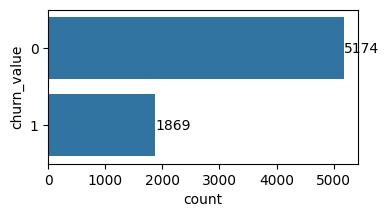

In [ ]:
fig,ax=plt.subplots(figsize=(4,2))
sns.countplot(y=df['churn_value'],ax=ax)
ax.bar_label(ax.containers[0], padding=0)
plt.savefig('target_analysis.png', dpi=500)
files.download('target_analysis.png')

##Seperating the columns based on datatypes
- Numeric cols\
From numerical columns we have to remove churn_value as that is the target variable so we can use that into hue

- Categorical cols\
We remove 'city' and 'churn_reason' because they have many unique or different values which may disturb the plots, but we will use them as well because they provide us many potential informations.

In [ ]:
categorical=df.select_dtypes(exclude='number').columns
categorical=categorical.drop(['city','churn_reason'])
numerical=df.select_dtypes(include='number').columns
numerical=numerical.drop('churn_value')
print(numerical)
categorical

Index(['tenure_months', 'monthly_charges', 'total_charges'], dtype='object')


Index(['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service',
       'multiple_lines', 'internet_service', 'online_security',
       'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies', 'contract', 'paperless_billing', 'payment_method'],
      dtype='object')

In [ ]:
df[categorical].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   gender             7043 non-null   object
 1   senior_citizen     7043 non-null   object
 2   partner            7043 non-null   object
 3   dependents         7043 non-null   object
 4   phone_service      7043 non-null   object
 5   multiple_lines     7043 non-null   object
 6   internet_service   7043 non-null   object
 7   online_security    7043 non-null   object
 8   online_backup      7043 non-null   object
 9   device_protection  7043 non-null   object
 10  tech_support       7043 non-null   object
 11  streaming_tv       7043 non-null   object
 12  streaming_movies   7043 non-null   object
 13  contract           7043 non-null   object
 14  paperless_billing  7043 non-null   object
 15  payment_method     7043 non-null   object
dtypes: object(16)
memory usage: 880.5+ KB


In [ ]:
list(df[categorical].nunique().sort_values().items())

[('gender', 2),
 ('senior_citizen', 2),
 ('partner', 2),
 ('dependents', 2),
 ('phone_service', 2),
 ('paperless_billing', 2),
 ('internet_service', 3),
 ('multiple_lines', 3),
 ('online_security', 3),
 ('online_backup', 3),
 ('tech_support', 3),
 ('device_protection', 3),
 ('streaming_tv', 3),
 ('streaming_movies', 3),
 ('contract', 3),
 ('payment_method', 4)]

#Univariate Analysis
###Categorical
* **Gender distribution** is nearly balanced, indicating no major skew in male vs female customers.

* **Senior citizens** represent a small portion of the dataset, while most customers are non-senior.

* A large number of customers **do not have dependents**.

* **Phone service** is used by the majority of customers.

* **Multiple lines** show a fairly balanced distribution between users and non-users.

* Among internet services, **Fiber optic is the most preferred**, followed by DSL, while a smaller group has no internet service.

* Most customers **do not subscribe to additional services** such as online security, backup, tech support, and device protection.

* **Streaming services** (TV and movies) show a relatively balanced usage pattern.

* **Month-to-month contracts dominate**, with significantly fewer customers on one-year or two-year contracts.

* **Paperless billing is more commonly used** than traditional billing methods.

* **Electronic check is the most widely used payment method**, followed by other payment options.

In [ ]:
fig,ax=plt.subplots(4,4,figsize=(30,22),dpi=500)
for i,cols in enumerate(categorical):
  row=i//4
  col=i%4
  sns.countplot(y=cols,data=df,ax=ax[row,col])
  ax[row, col].set_title(cols)
  ax[row,col].bar_label(ax[row,col].containers[0],padding=0)
plt.savefig('cat_uni.png', dpi=500)
plt.tight_layout()
files.download('cat_uni.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###Numerical
* **tenure_months** shows customers are either new or old (mostly).
* **monthly_charges** show majority of customers have low charges but it is still fairly spreaded.
* **total_charges** is a right or positively skewed indicating that there may be outliers present in this variable.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

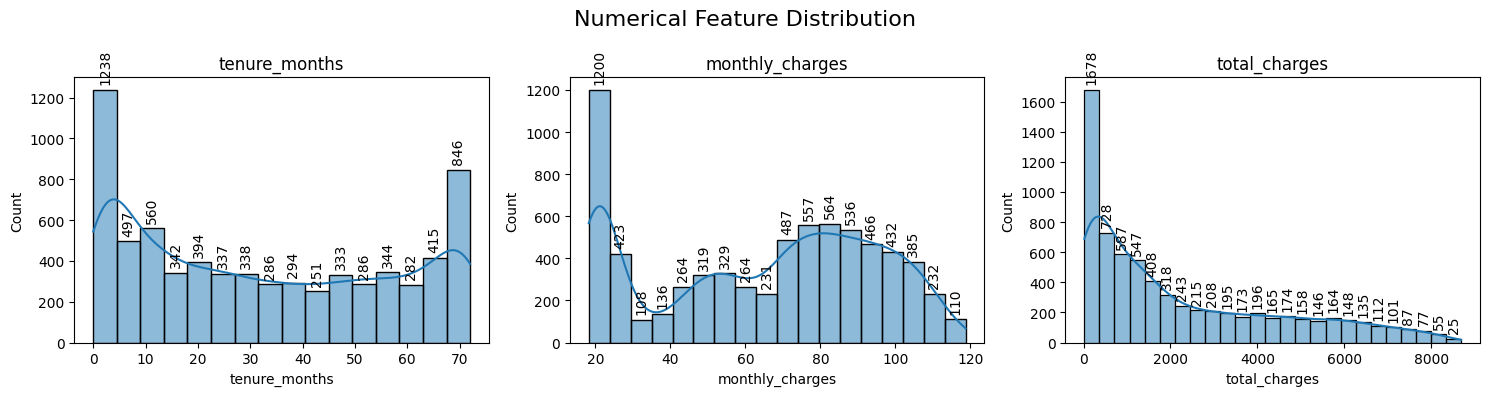

In [ ]:
fig, ax = plt.subplots(1, len(numerical), figsize=(15,4))
fig.suptitle("Numerical Feature Distribution", fontsize=16)
for i, col in enumerate(numerical):
    sns.histplot(df[col], kde=True, ax=ax[i])
    ax[i].bar_label(ax[i].containers[0],padding=4,rotation=90)
    ax[i].set_title(col)
plt.savefig('num_uni.png', dpi=500)
plt.tight_layout()
files.download('num_uni.png')

#Bivariate Analysis

### Categorical (Bivariate Analysis)

* **contract** customer with low tenure or month to month contract tends to leave whereas long term customers stay.
* **internet_service** tells us that premium or rich customers churn more (fiber optics connection).
* **Electronic_check** payment method has the highest churn rate.
* Customers without **tech support or online security** are more likely to churn.
* **Paperless_billing** users show relatively higher churn.

Contract type and additional featurs are high indicators for the churn reason.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

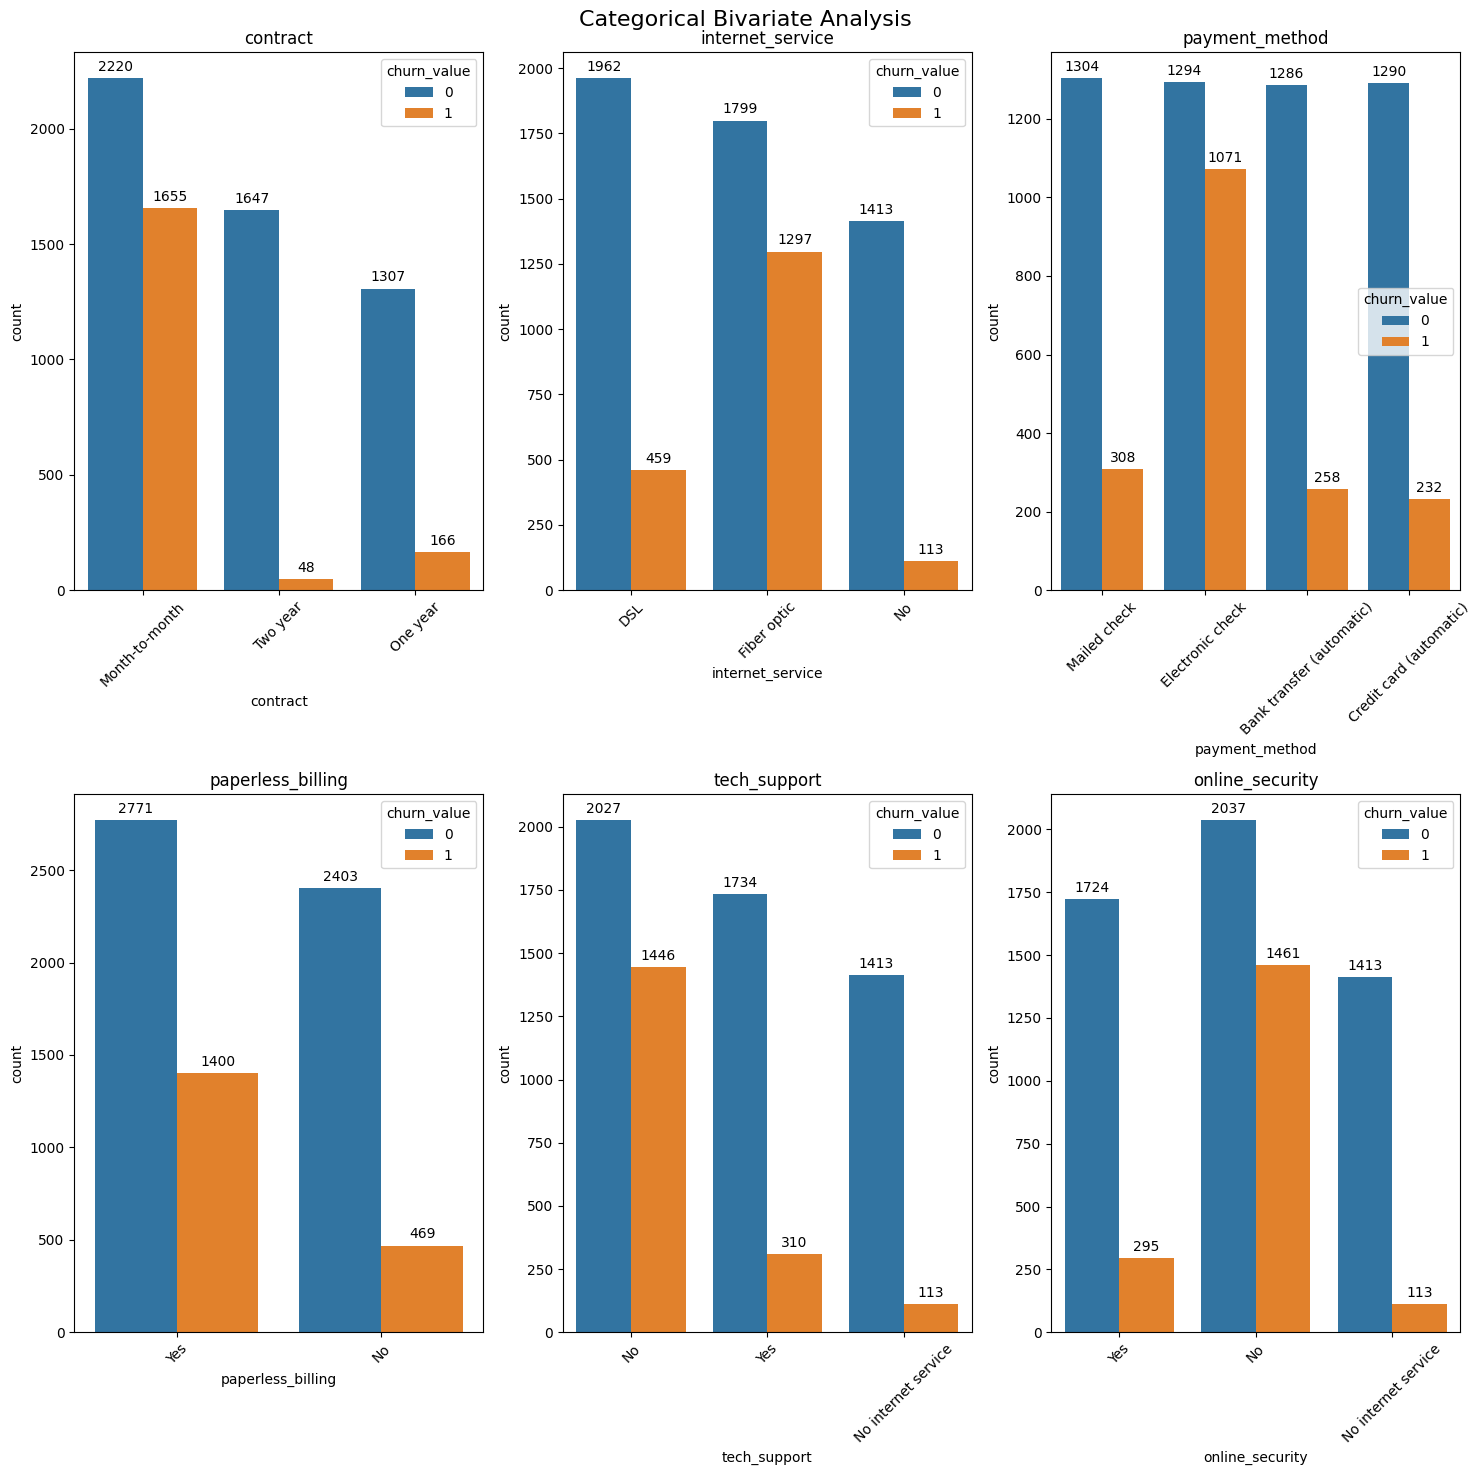

In [ ]:
bi_cat=['contract','internet_service','payment_method','paperless_billing','tech_support','online_security']
fig , ax=plt.subplots(2, 3,figsize=(15,15))
fig.suptitle("Categorical Bivariate Analysis", fontsize=16)
for i,cols in enumerate(bi_cat):
  row=i//3
  col=i%3
  sns.countplot(x=cols, hue='churn_value',data=df ,ax=ax[row,col])
  ax[row, col].set_title(cols)
  ax[row, col].tick_params(axis='x', rotation=45)
  for container in ax[row, col].containers:
        ax[row, col].bar_label(container, padding=3)
plt.savefig('cat_bi.png', dpi=500)
plt.tight_layout()
files.download('cat_bi.png')

### Numerical (Bivariate Analysis)

* Customers with **low tenure** are more likely to churn, while long-term customers tend to stay, maybe because of the pricing.
* Mostly customers falls in lower **monthly charges** but churned customers are associated with higher charges.
* **total_charges** depends on the tenure so customers tend to leave who have low total charges because of short tenure.

Tenure is the strongest predictor of churn, followed by monthly charges.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

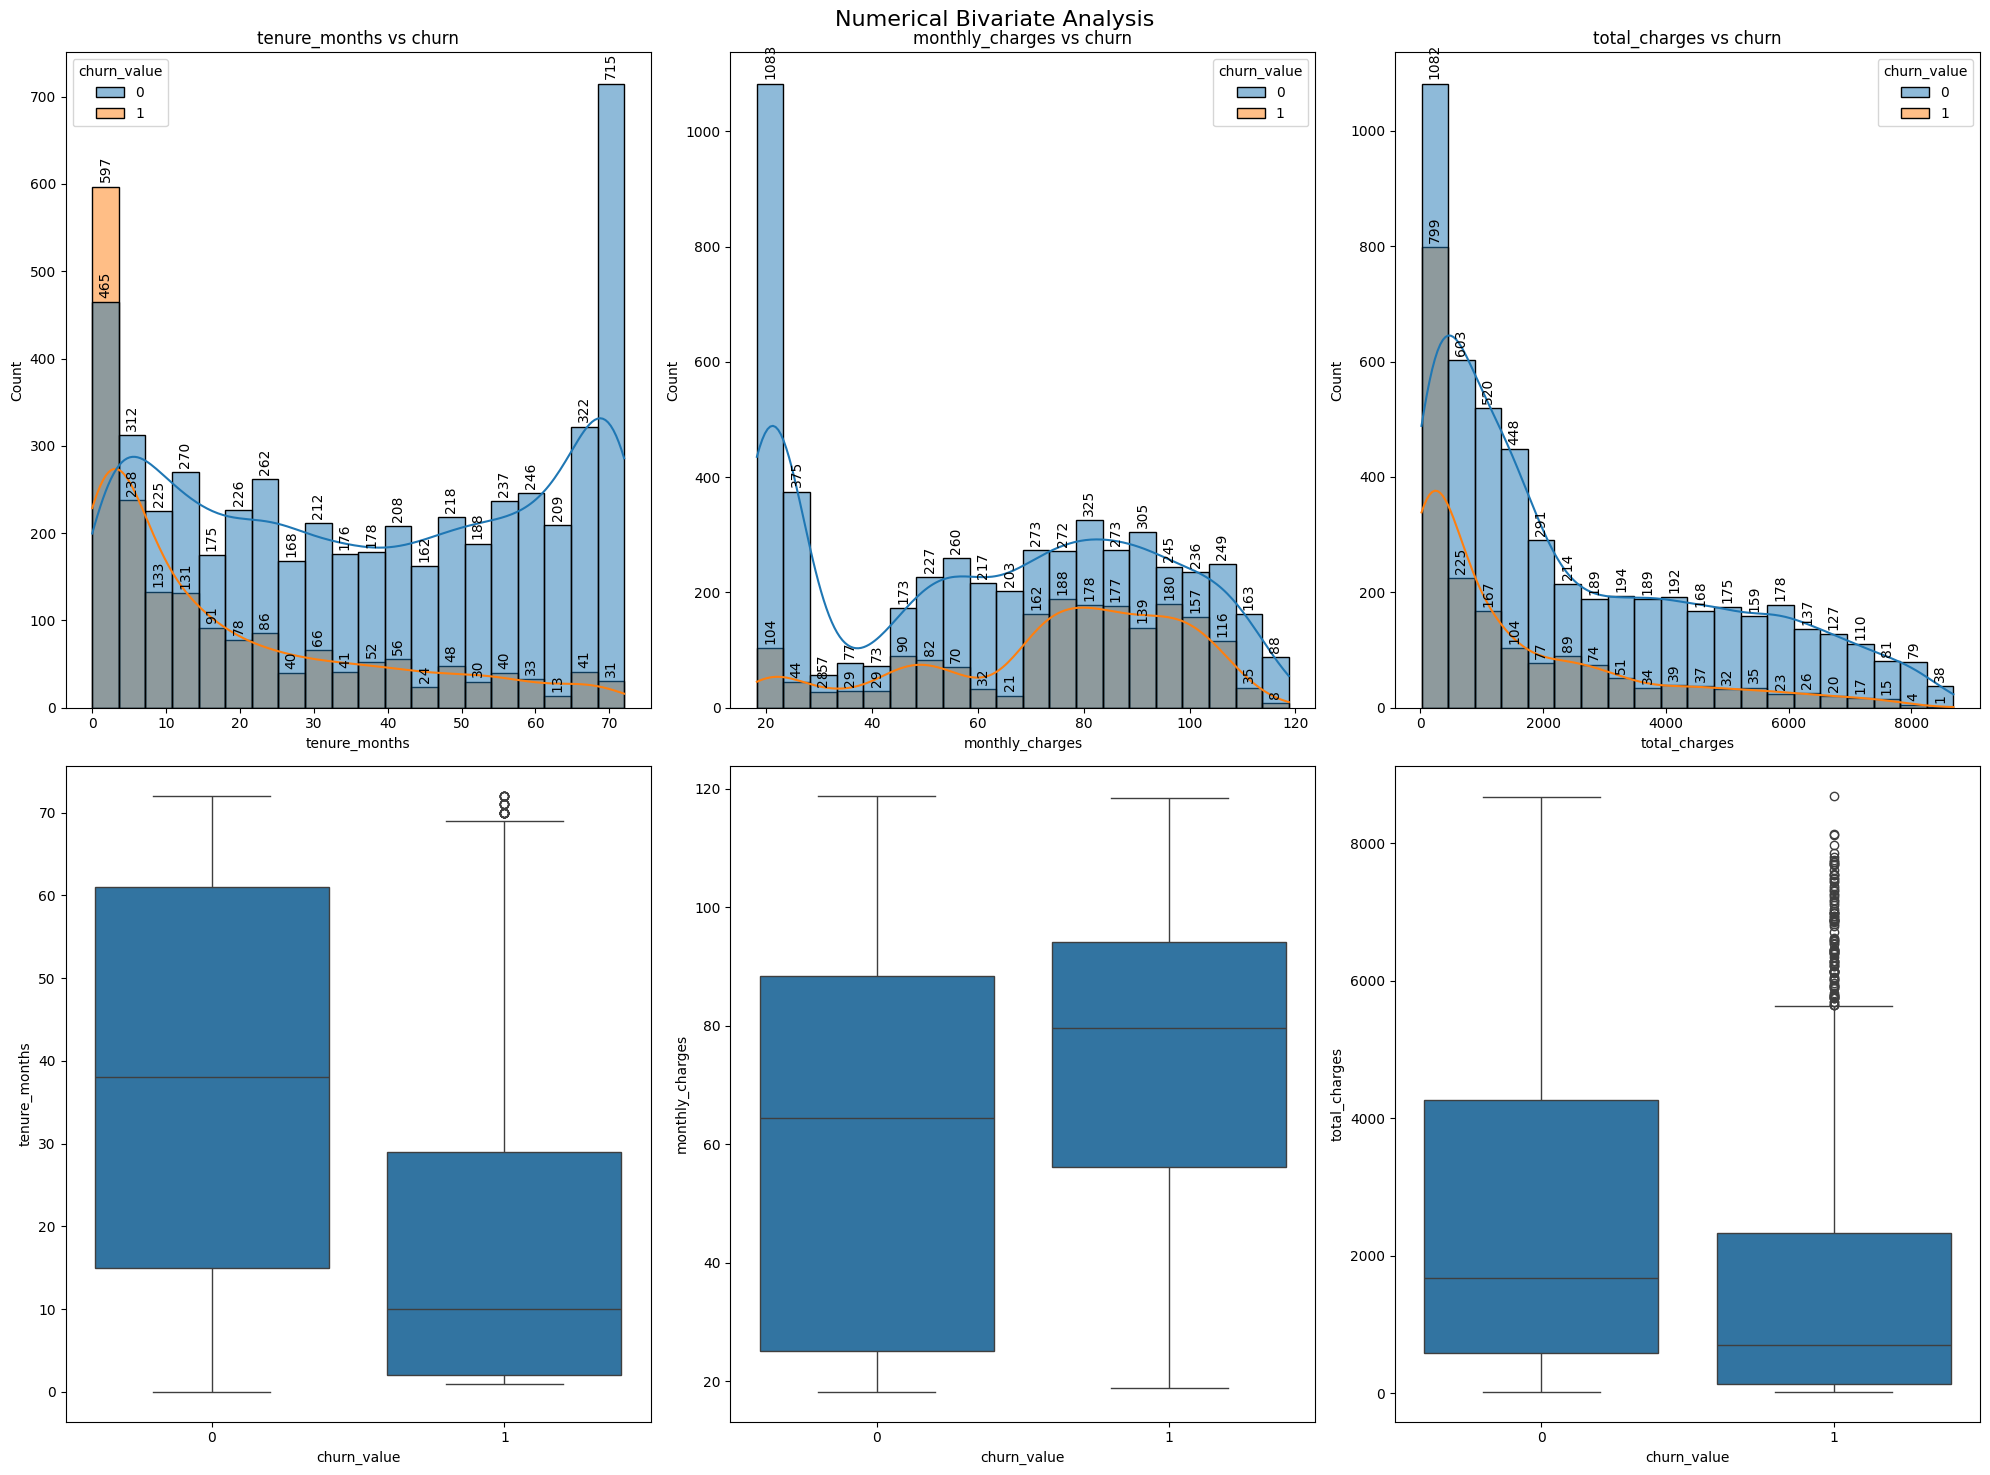

In [ ]:
fig,ax=plt.subplots(2,3,figsize=(20,15))
fig.suptitle("Numerical Bivariate Analysis", fontsize=16)
for i , cols in enumerate(numerical):
  row=i//3
  col=i%3
  sns.histplot(x=cols,hue='churn_value', data=df, ax=ax[row,col], bins=20 ,kde=True)
  for container in ax[row, col].containers:
        ax[row, col].bar_label(container, padding=3,rotation=90)
  ax[row, col].set_title(f'{cols} vs churn')
  sns.boxplot(x='churn_value', y=cols, data=df, ax=ax[1,col])
plt.savefig('num_bi.png', dpi=500)
plt.tight_layout()
files.download('num_bi.png')

#Churn Reason
We need to know why customers are churning to tackele the effect, through this analysis we can get the most common reasons of churning and how many months a person stays because of that particular reason and what may be the top resons of the churn based on the contact type.

In [ ]:
churn_df=df[df['churn_value']==1]
churn_df.shape

(1869, 22)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

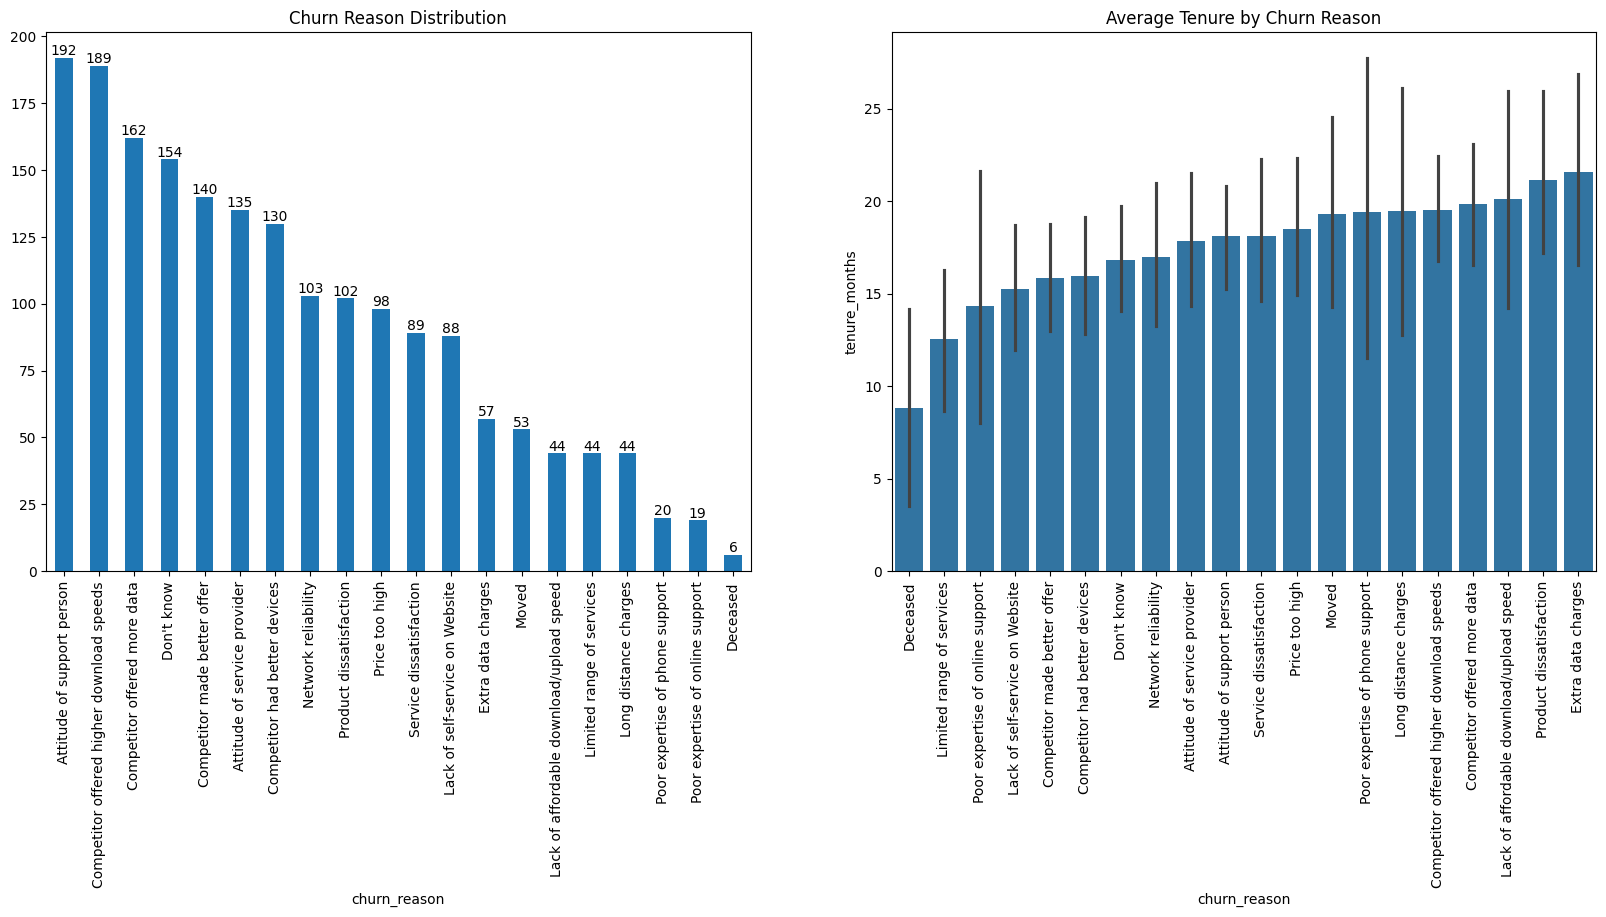

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(20,7))
churn_df['churn_reason'].value_counts().plot(kind='bar', ax=ax[0])
ax[0].set_title('Churn Reason Distribution')
ax[0].bar_label(ax[0].containers[0],padding=0)
order = churn_df.groupby('churn_reason')['tenure_months'].mean().sort_values().index
sns.barplot(x='churn_reason',y='tenure_months',data=churn_df,order=order,ax=ax[1])
ax[1].set_title('Average Tenure by Churn Reason')
ax[1].tick_params(axis='x', rotation=90)
plt.savefig('churn_reason.png', dpi=500)
files.download('churn_reason.png')

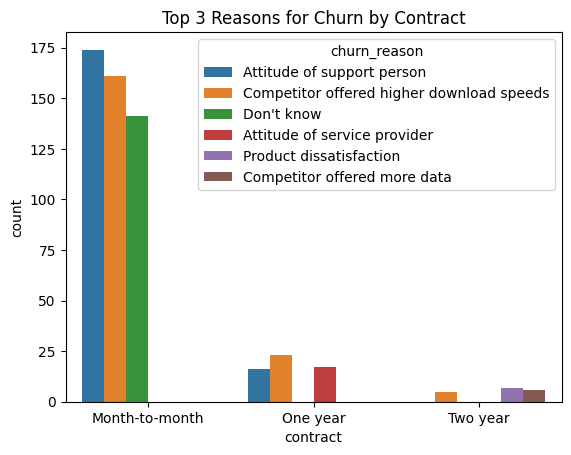

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
top3=churn_df.groupby('contract')['churn_reason'].value_counts().groupby(level=0).head(3).reset_index(name='count')
sns.barplot(x='contract',y='count',hue='churn_reason',data=top3)
plt.title('Top 3 Reasons for Churn by Contract')
plt.savefig('churn_contract.png', dpi=500)
plt.show()
files.download('churn_contract.png')

#Top Cities
Here we can find the top cities which have high customer count as well as churn rate ,so we can tackle the new customers from these cities more specifically.

In [ ]:
city_stat = df.groupby('city').agg(churn=('churn_value','mean'),count=('churn_value','count'))
city_stat=city_stat[city_stat['count']>50]
city_stat['churn']=city_stat['churn']*100
top_city=city_stat.sort_values(by='churn',ascending=False).head(5)
top_city

,churn,count
city,,
San Diego,33.333333,150
San Francisco,29.807692,104
Los Angeles,29.508197,305
San Jose,25.892857,112
Oakland,25.000000,52


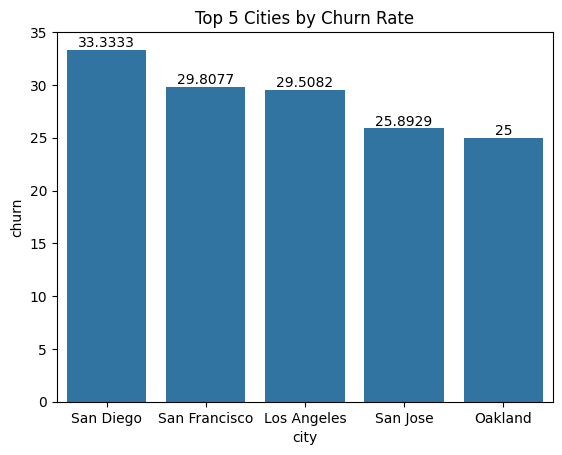

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
ax=sns.barplot(x='city',y='churn',data=top_city)
plt.title('Top 5 Cities by Churn Rate')
ax.bar_label(ax.containers[0],padding=0)
plt.savefig('top_city.png', dpi=500)
plt.show()
files.download('top_city.png')

#Correlation

###Numerical
* **Tenure** has the highest negative correlation with churn (-0.35) that can say new customers are at higher risk of leaving.
* **Monthly charges** show a weak positive correlation (0.19) so higher charges slightly increase churn rate.
* **total_charges** has weak negative correlation (-0.19) Less impactful compared to tenure.

* Feature Redundency Score b/w **tenure_months** & **total_charges** = 0.82\
That means they both carry similar featues or information which can be noisy for model building, but as tenure has higher corellation that total_charges we use it and can drop **total_charges**.

Tenure shows the strongest negative correlation with churn, indicating that customers who remain longer with the company are less likely to leave. Monthly charges have a mild positive relationship with churn, suggesting that higher pricing may contribute to customer churn. Whereas, total charges show high redundancy with tenure and can have similar information.

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix=numeric_df.corr()
corr_matrix

,tenure_months,monthly_charges,total_charges,churn_value
tenure_months,1.000000,0.247900,0.825464,-0.352229
monthly_charges,0.247900,1.000000,0.650864,0.193356
total_charges,0.825464,0.650864,1.000000,-0.199037
churn_value,-0.352229,0.193356,-0.199037,1.000000


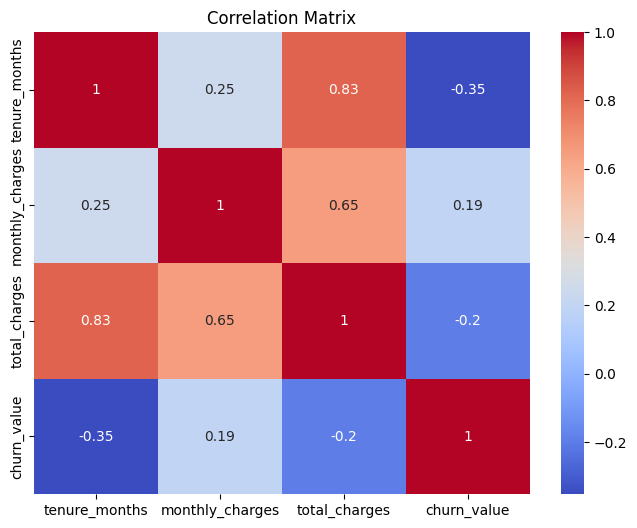

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.savefig('corr.png', dpi=500)
plt.show()
files.download('corr.png')

In [ ]:
corr_matrix['churn_value'].sort_values(ascending=False)

,churn_value
churn_value,1.000000
monthly_charges,0.193356
total_charges,-0.199037
tenure_months,-0.352229


In [ ]:
#redundency
corr_matrix['tenure_months']['total_charges']

np.float64(0.8254640864072993)

###Categrical
* Customers with month-to-month contracts show the highest churn rate (~42%).
* other columns also have significant feature or individual values that is responsible for the maximum churn in that particular column.

In [ ]:
for col in bi_cat:
 temp=pd.DataFrame(df.groupby(col)['churn_value'].mean()*100)
 print(temp)

                churn_value
contract                   
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
                  churn_value
internet_service             
DSL                 18.959108
Fiber optic         41.892765
No                   7.404980
                           churn_value
payment_method                        
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
                   churn_value
paperless_billing             
No                   16.330084
Yes                  33.565092
                     churn_value
tech_support                    
No                     41.635474
No internet service     7.404980
Yes                    15.166341
                     churn_value
online_security                 
No                     41.766724
No internet service     7.404980
Yes                    14.611194


In [ ]:
churn_df = pd.DataFrame(columns=['column_name','col_feature','churn_percentage'])
for col in bi_cat:
    temp = df.groupby(col)['churn_value'].mean()*100
    max_cat = temp.idxmax()
    max_val = temp.max()
    new_row = {'column_name': col,'col_feature': max_cat,'churn_percentage': max_val}
    churn_df = pd.concat([churn_df, pd.DataFrame([new_row])], ignore_index=True)
churn_df

,column_name,col_feature,churn_percentage
0,contract,Month-to-month,42.709677
1,internet_service,Fiber optic,41.892765
2,payment_method,Electronic check,45.285412
3,paperless_billing,Yes,33.565092
4,tech_support,No,41.635474
5,online_security,No,41.766724


#Outlier Detction
Outlier detection was performed using the IQR method.  
No significant outliers were found in numerical features, as all values lie within acceptable bounds.  
Although minor deviations were observed when segmented by churn, they represent natural behavioral differences rather than anomalies.  
Hence, no outlier treatment was applied.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

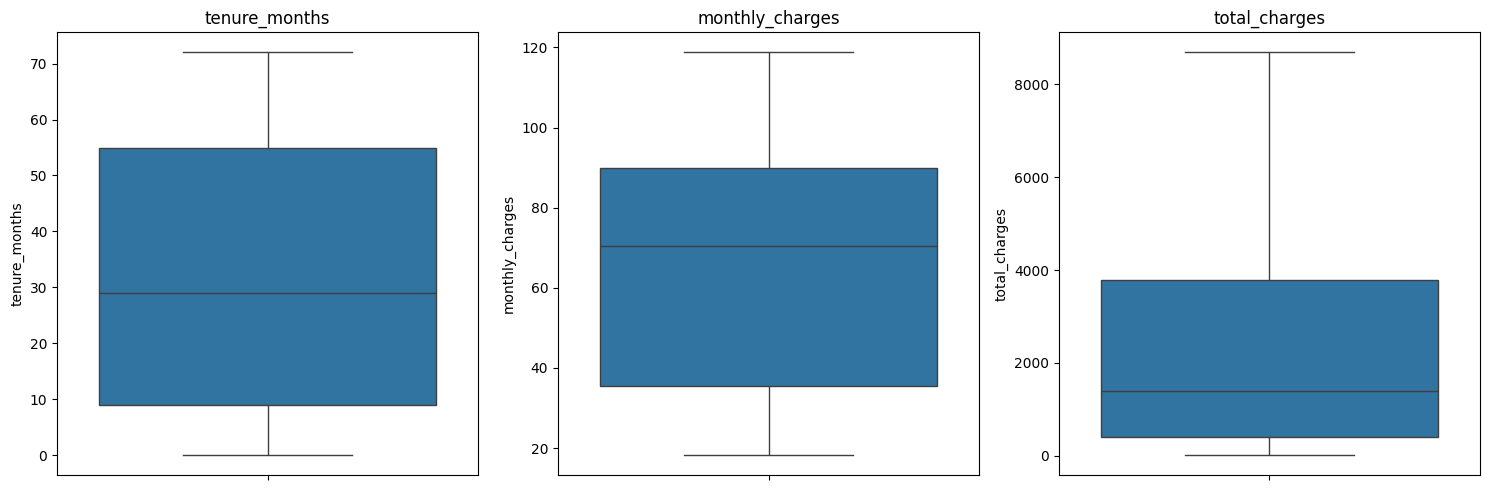

In [ ]:
fig, ax=plt.subplots(1,len(numerical),figsize=(15,5))
for i,cols in enumerate(numerical):
  sns.boxplot(y=cols,data=df,ax=ax[i])
  ax[i].set_title(cols)
plt.savefig('out_num.png', dpi=500)
plt.tight_layout()
files.download('out_num.png')

In [ ]:
out={'tenure_months':[],'monthly_charges':[],'total_charges':[]}
for cols in numerical:
  print(f'{cols} min={df[cols].min()} max={df[cols].max()}')
  q1=df[cols].quantile(0.25)
  q3=df[cols].quantile(0.75)
  iqr=q3-q1
  lower = q1-(1.5*iqr)
  upper = q3+(1.5*iqr)
  print(f'{cols}: q1={q1} q3={q3} iqr={iqr} lower={lower} upper={upper}')
  outliers=df[cols].loc[(df[cols]<lower) | (df[cols]>upper)].index.tolist()
  out[cols].extend(outliers)

tenure_months min=0 max=72
tenure_months: q1=9.0 q3=55.0 iqr=46.0 lower=-60.0 upper=124.0
monthly_charges min=18.25 max=118.75
monthly_charges: q1=35.5 q3=89.85 iqr=54.349999999999994 lower=-46.02499999999999 upper=171.375
total_charges min=18.8 max=8684.8
total_charges: q1=402.225 q3=3786.6 iqr=3384.375 lower=-4674.3375 upper=8863.1625


In [ ]:
out

{'tenure_months': [], 'monthly_charges': [], 'total_charges': []}